## Xử lý ảnh

## INT3404 20 ----- 8-10 Monday - 209GD3
## Diep Ng., Ph.D.

### Mail-to: ngocdiep at vnu.edu.vn



In [1]:
!python --version

Python 3.10.14


# Tuần 4: Phép lọc (Filters)


Ref: https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.correlate2d.html

- `mode`: str {‘full’, ‘valid’, ‘same’}, optional
             A string indicating the size of the output:

            + full
                The output is the full discrete linear cross-correlation of the inputs. (Default)

            + valid
                The output consists only of those elements that do not rely on the zero-padding. In ‘valid’ mode, either in1 or in2 must be at least as large as the other in every dimension.

            + same
                The output is the same size as in1, centered with respect to the ‘full’ output.

- `boundary` : str {‘fill’, ‘wrap’, ‘symm’}, optional
                A flag indicating how to handle boundaries:

            + fill
                pad input arrays with fillvalue. (default)

            + wrap
                circular boundary conditions.

            + symm
                symmetrical boundary conditions.

- `fillvalue` : scalar, optional
                Value to fill pad input arrays with. Default is 0.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [3]:
%matplotlib inline

In [4]:
plt.rcParams['figure.figsize'] = [8, 6]

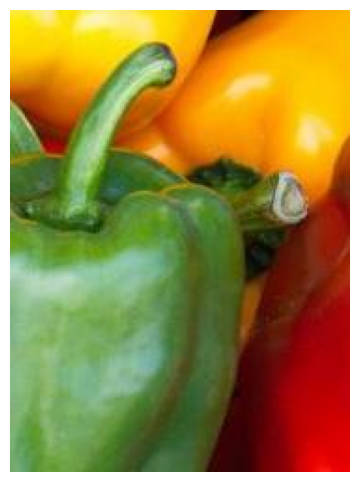

In [5]:
image = cv2.imread("pepper.jpg")
plt.imshow(image[...,::-1])
plt.axis("off")
plt.show()

In [6]:
def rgb_filter(image, kernel, mode='full', boundary='fill'):
    b,g,r = cv2.split(image)
    b = signal.correlate2d(b, kernel, mode=mode, boundary=boundary)
    g = signal.correlate2d(g, kernel, mode=mode, boundary=boundary)
    r = signal.correlate2d(r, kernel, mode=mode, boundary=boundary)
    output = cv2.merge([b,g,r])
    return output

Original shape:  (248, 182, 3)
Filtered shape:  (268, 202, 3)


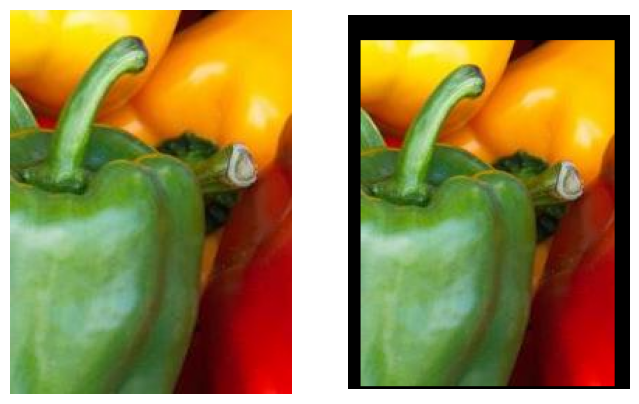

In [7]:
# make a kernel
kernel = np.zeros((21, 21), dtype='uint8')
kernel[2,11] = 1

# MxN, mxn,
#FUll: M+m-1 = 248 +21 -1
#do cross correlation
fimage = rgb_filter(image, kernel, mode='full', boundary='fill')

#check the size of image
print("Original shape: ", image.shape)
print("Filtered shape: ", fimage.shape)

#view the image
plt.subplot(1, 2, 1); plt.imshow(image[:,:,::-1]); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(fimage[:,:,::-1]); plt.axis("off")
plt.show()


Original shape:  (248, 182, 3)
Filtered shape:  (268, 202, 3)


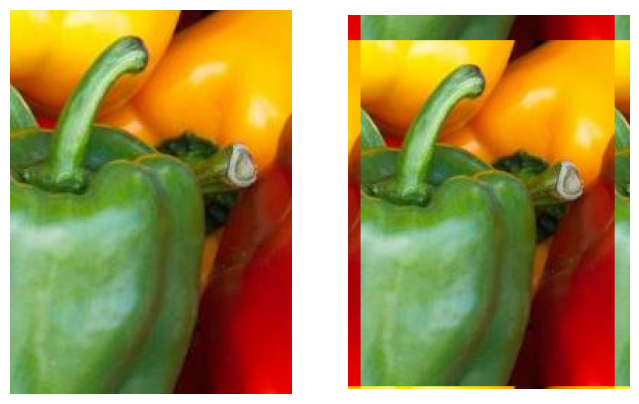

In [8]:
#do cross correlation
fimage = rgb_filter(image, kernel, mode='full', boundary='wrap')

#check the size of image
print("Original shape: ", image.shape)
print("Filtered shape: ", fimage.shape)

#view the image
plt.subplot(1, 2, 1); plt.imshow(image[:,:,::-1]); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(fimage[:,:,::-1]); plt.axis("off")
plt.show()

Original shape:  (248, 182, 3)
Filtered shape:  (268, 202, 3)


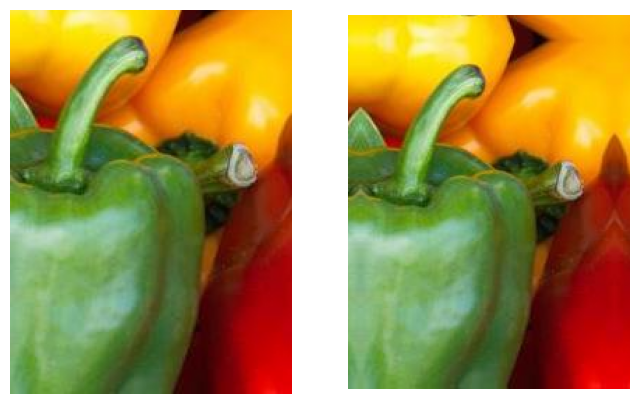

In [9]:
#symmetry boundary
fimage = rgb_filter(image, kernel, mode='full', boundary='symm')

#check the size of image
print("Original shape: ", image.shape)
print("Filtered shape: ", fimage.shape)

#view the image
plt.subplot(1, 2, 1); plt.imshow(image[:,:,::-1]); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(fimage[:,:,::-1]); plt.axis("off")
plt.show()

Original shape:  (248, 182, 3)
Filtered shape:  (228, 162, 3)


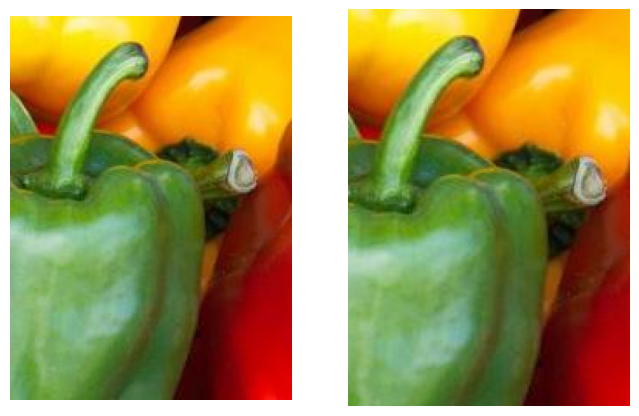

In [10]:
#valid filtering
fimage = rgb_filter(image, kernel, mode='valid', boundary='symm')

#check the size of image
print("Original shape: ", image.shape)
print("Filtered shape: ", fimage.shape)  ##should decrease

#view the image
plt.subplot(1, 2, 1); plt.imshow(image[:,:,::-1]); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(fimage[:,:,::-1]); plt.axis("off")
plt.show()

Original shape:  (248, 182, 3)
Filtered shape:  (248, 182, 3)


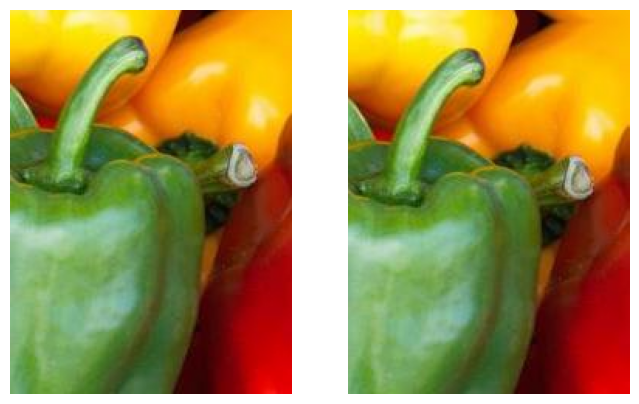

In [11]:
#same filtering
fimage = rgb_filter(image, kernel, mode='same', boundary='symm')

#check the size of image
print("Original shape: ", image.shape)
print("Filtered shape: ", fimage.shape)  ##equal

#view the image
plt.subplot(1, 2, 1); plt.imshow(image[:,:,::-1]); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(fimage[:,:,::-1]); plt.axis("off")
plt.show()

## Using opencv


In [21]:
cv2.filter2D?

Docstring:
filter2D(src, ddepth, kernel[, dst[, anchor[, delta[, borderType]]]]) -> dst
.   @brief Convolves an image with the kernel.
.   
.   The function applies an arbitrary linear filter to an image. In-place operation is supported. When
.   the aperture is partially outside the image, the function interpolates outlier pixel values
.   according to the specified border mode.
.   
.   The function does actually compute correlation, not the convolution:
.   
.   \f[\texttt{dst} (x,y) =  \sum _{ \substack{0\leq x' < \texttt{kernel.cols}\\{0\leq y' < \texttt{kernel.rows}}}}  \texttt{kernel} (x',y')* \texttt{src} (x+x'- \texttt{anchor.x} ,y+y'- \texttt{anchor.y} )\f]
.   
.   That is, the kernel is not mirrored around the anchor point. If you need a real convolution, flip
.   the kernel using #flip and set the new anchor to `(kernel.cols - anchor.x - 1, kernel.rows -
.   anchor.y - 1)`.
.   
.   The function uses the DFT-based algorithm in case of sufficiently large kernels (~`11 x 11`

Original shape:  (248, 182, 3)
Filtered shape:  (248, 182, 3)


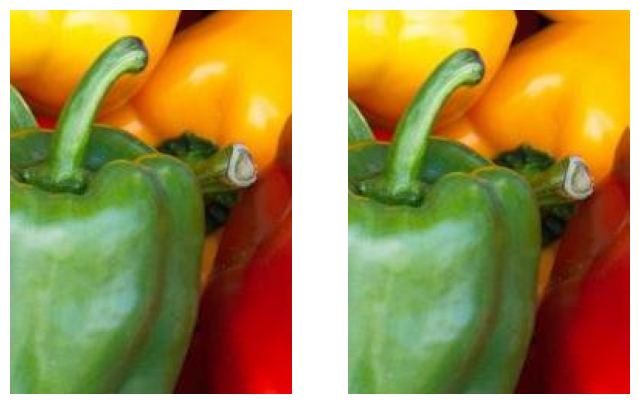

In [ ]:

# tính convolution từ kernel trên ảnh 
fimage = cv2.filter2D(image, -1, kernel, cv2.BORDER_DEFAULT)

#check the size of image
print("Original shape: ", image.shape)
print("Filtered shape: ", fimage.shape)  ##should decrease

#view the image
plt.subplot(1, 2, 1); plt.imshow(image[:,:,::-1]); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(fimage[:,:,::-1]); plt.axis("off")
plt.show()

## Averaging

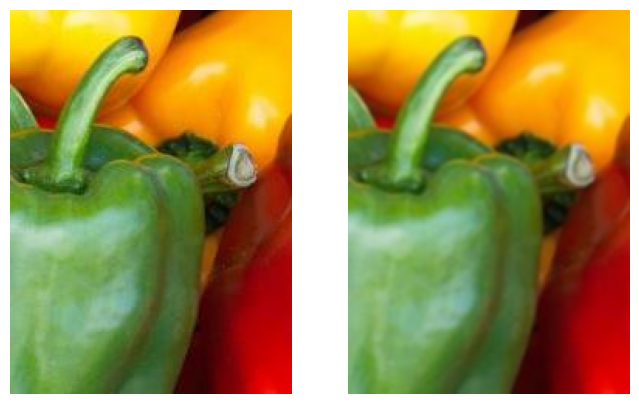

In [15]:
kernel = 1/9 * np.array([
                [1, 1, 1],
                [1, 1, 1],
                [1, 1, 1]
])

#averaging for a smoothing effect
fimage = cv2.filter2D(image, -1, kernel)
plt.subplot(1, 2, 1); plt.imshow(image[:,:,::-1]); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(fimage[:,:,::-1]); plt.axis("off")
plt.show()

## Gaussian Filtering

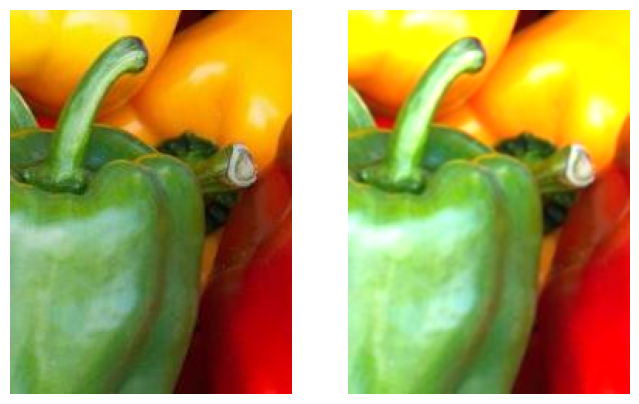

In [16]:
#a gaussian kernel

kernel = 1/12 * np.array([
                [1, 2, 1],
                [2, 4, 2],
                [1, 2, 1]
])

#averaging for a smoothing effect
fimage = cv2.filter2D(image, -1, kernel)
plt.subplot(1, 2, 1); plt.imshow(image[:,:,::-1]); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(fimage[:,:,::-1]); plt.axis("off")
plt.show()

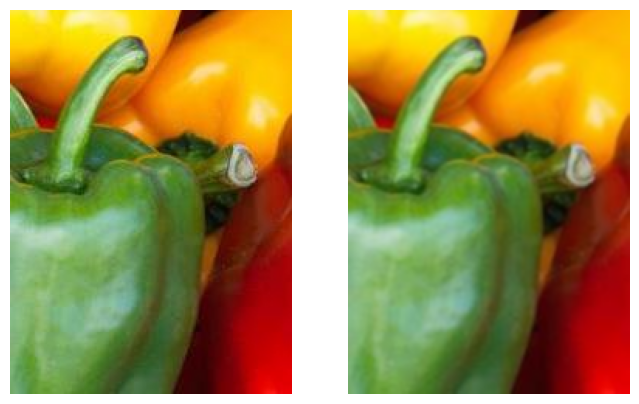

In [17]:
#or using GaussianBlur

fimage = cv2.GaussianBlur(image, (3,3), 0) #image, kernel size, sigma
plt.subplot(1, 2, 1); plt.imshow(image[:,:,::-1]); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(fimage[:,:,::-1]); plt.axis("off")
plt.show()

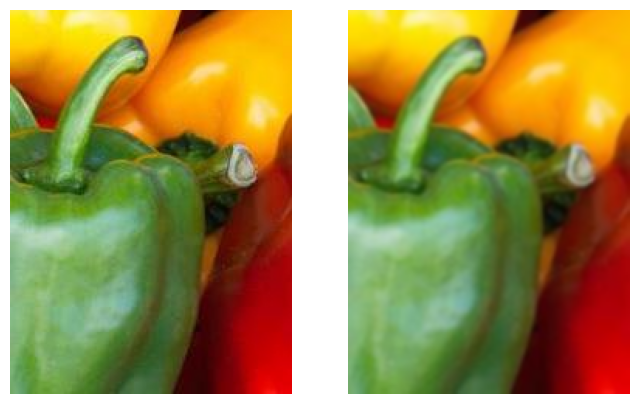

In [18]:
fimage = cv2.GaussianBlur(image, (5, 5), 0) #image, kernel size, sigma
plt.subplot(1, 2, 1); plt.imshow(image[:,:,::-1]); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(fimage[:,:,::-1]); plt.axis("off")
plt.show()

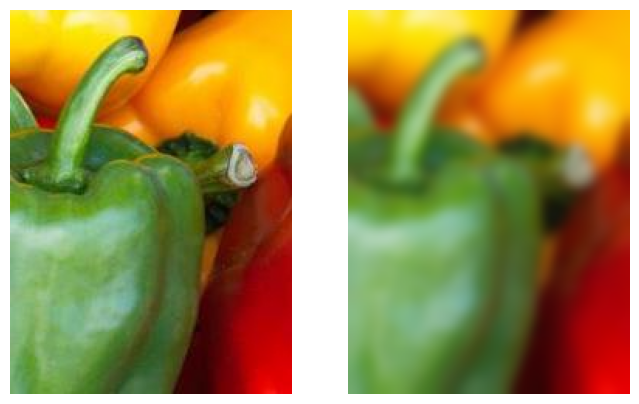

In [19]:
fimage = cv2.GaussianBlur(image, (21,21), 0) #image, kernel size, sigma
plt.subplot(1, 2, 1); plt.imshow(image[:,:,::-1]); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(fimage[:,:,::-1]); plt.axis("off")
plt.show()

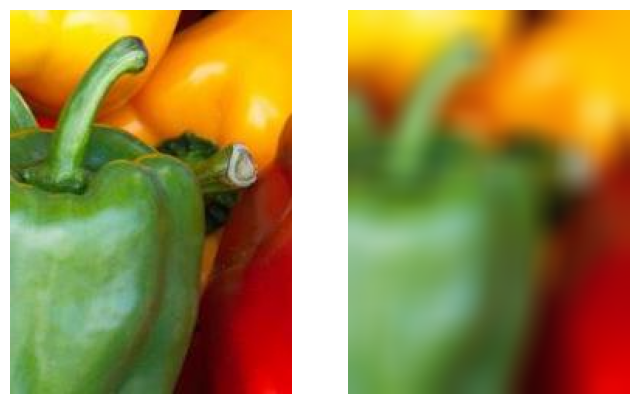

In [20]:
fimage = cv2.GaussianBlur(image, (21, 21), 20) #image, kernel size, sigma
plt.subplot(1, 2, 1); plt.imshow(image[:,:,::-1]); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(fimage[:,:,::-1]); plt.axis("off")
plt.show()

=> sử dụng ma trận gaussian làm mờ ảnh 

## Median filtering


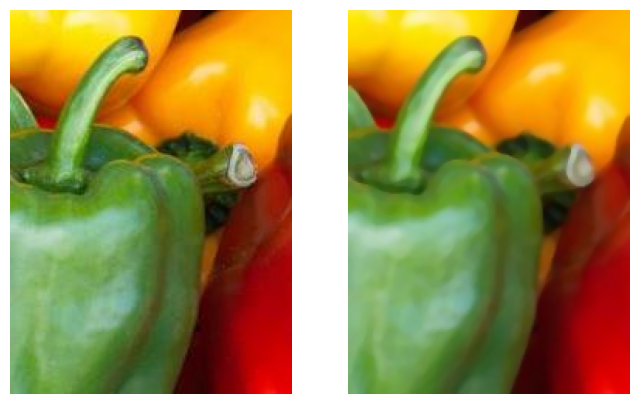

In [21]:
fimage = cv2.medianBlur(image, 5) #image, kernel size
plt.subplot(1, 2, 1); plt.imshow(image[:,:,::-1]); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(fimage[:,:,::-1]); plt.axis("off")
plt.show()

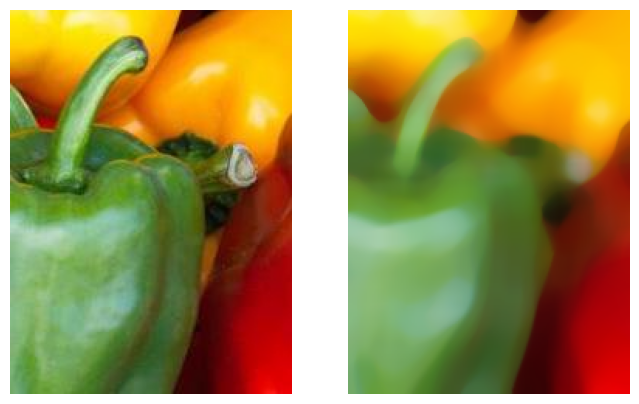

In [22]:
fimage = cv2.medianBlur(image, 21) #image, kernel size
plt.subplot(1, 2, 1); plt.imshow(image[:,:,::-1]); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(fimage[:,:,::-1]); plt.axis("off")
plt.show()

(-0.5, 181.5, 247.5, -0.5)

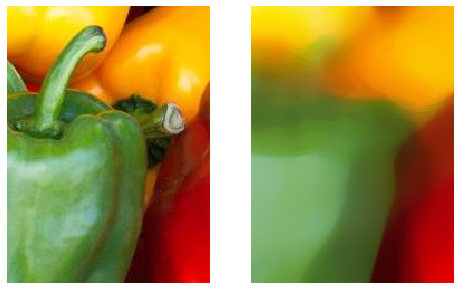

In [ ]:
fimage = cv2.medianBlur(image, 45) #image, kernel size
plt.subplot(1, 2, 1); plt.imshow(image[:,:,::-1]); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(fimage[:,:,::-1]); plt.axis("off")

## Unsharp masking

$dst = \alpha \cdot src1 + \beta \cdot src2 + \gamma$

Where `src2` is a blurred image

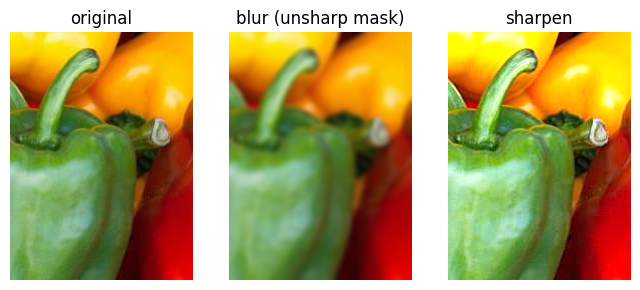

In [23]:
blur = cv2.GaussianBlur(image, (7,7), 3.0)
fimage = cv2.addWeighted(image, 1.7, blur, -0.5, 0)
plt.subplot(1, 3, 1); plt.imshow(image[:,:,::-1]); plt.axis("off"); plt.title("original")
plt.subplot(1, 3, 2); plt.imshow(blur[:,:,::-1]); plt.axis("off"); plt.title("blur (unsharp mask)")
plt.subplot(1, 3, 3); plt.imshow(fimage[:,:,::-1]); plt.axis("off"); plt.title("sharpen")
plt.show()

Text(0.5, 1.0, 'sharpen')

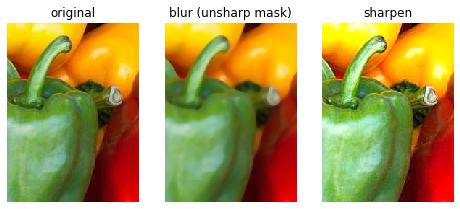

In [ ]:
blur = cv2.medianBlur(image, 7)
fimage = cv2.addWeighted(image, 1.7, blur, -0.5, 0)
plt.subplot(1, 3, 1); plt.imshow(image[:,:,::-1]); plt.axis("off"); plt.title("original")
plt.subplot(1, 3, 2); plt.imshow(blur[:,:,::-1]); plt.axis("off"); plt.title("blur (unsharp mask)")
plt.subplot(1, 3, 3); plt.imshow(fimage[:,:,::-1]); plt.axis("off"); plt.title("sharpen")

## Arbitrary filters


(-0.5, 181.5, 247.5, -0.5)

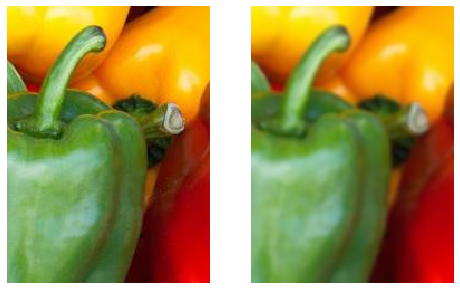

In [ ]:
#a gaussian kernel

kernel = np.random.rand(5,5)
kernel = kernel/sum(kernel.ravel())

#averaging for a smoothing effect
fimage = cv2.filter2D(image, -1, kernel)
plt.subplot(1, 2, 1); plt.imshow(image[:,:,::-1]); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(fimage[:,:,::-1]); plt.axis("off")


(-0.5, 181.5, 247.5, -0.5)

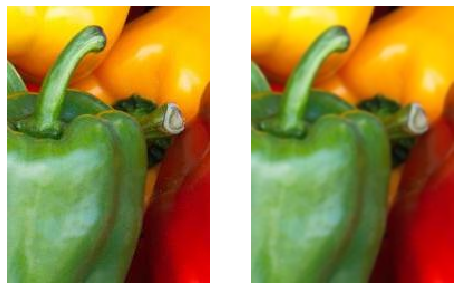

In [ ]:
fimage = cv2.GaussianBlur(image, (5,5), 1.0, cv2.BORDER_REFLECT)
plt.subplot(1, 2, 1); plt.imshow(image[:,:,::-1]); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(fimage[:,:,::-1]); plt.axis("off")


Bonus point tasks:
- (0.5pt midterm): Prove properties of Convolution operation
- (0.5pt midterm): Describe fast computation (efficient implementation) for convolution (on CPU, on GPU)